# 🗳️ ElectioAnalytics — Machine Learning
## Prédiction du bloc vainqueur — Nord (59)

**Variable cible :** `bloc_vainqueur` (GAUCHE / CENTRE / DROITE / DIVERS)  
**Train :** élections 2017 × socio-éco 2016  
**Test :** élections 2022 × socio-éco 2021  
**Algorithmes :** Random Forest · Logistic Regression · SVM · KNN · Gradient Boosting

---


## 0. Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

# Affichage pandas
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", "{:.2f}".format)

print("✅ Imports OK")


✅ Imports OK


## 1. Chargement des données

In [2]:
TRAIN_PATH = "data/final/ml_dataset_2017.csv"
TEST_PATH  = "data/final/ml_dataset_2022.csv"

df_train = pd.read_csv(TRAIN_PATH, dtype={"code_commune": str, "code_geo": str})
df_test  = pd.read_csv(TEST_PATH,  dtype={"code_commune": str, "code_geo": str})

print(f"Train 2017 : {df_train.shape[0]} communes × {df_train.shape[1]} colonnes")
print(f"Test  2022 : {df_test.shape[0]}  communes × {df_test.shape[1]} colonnes")
df_train.head(3)


Train 2017 : 648 communes × 38 colonnes
Test  2022 : 648  communes × 38 colonnes


,code_geo,code_commune,libelle_commune,annee,inscrits,abstentions,votants,exprimes,pct_abstention,nom_cand1,nom_cand2,nom_cand3,nom_cand4,nom_cand5,pct_cand1,pct_cand2,pct_cand3,pct_cand4,pct_cand5,bloc_cand1,bloc_cand2,bloc_cand3,bloc_cand4,bloc_cand5,pct_CENTRE,pct_DIVERS,pct_DROITE,pct_GAUCHE,bloc_vainqueur,taux_chomage,nb_chomeurs,nb_actifs,population_mun,population_tot,taux_delinquance,nb_faits_total,nb_indicateurs,bloc_vainqueur_encoded
0,59001,00001,Abancourt,2017,358,42,316,311,11.73,LE PEN,FILLON,MACRON,MÉLENCHON,DUPONT-AIGNAN,30.23,21.54,18.33,13.83,6.43,DROITE,DROITE,CENTRE,GAUCHE,DROITE,18.33,3.22,58.20,20.26,DROITE,9.09,19.91,219.05,461,474,0.00,0.00,7.00,2
1,59002,00002,Abscon,2017,2805,557,2248,2188,19.86,LE PEN,MÉLENCHON,MACRON,FILLON,HAMON,42.55,22.62,14.95,8.87,4.20,DROITE,GAUCHE,CENTRE,DROITE,GAUCHE,14.95,1.01,55.58,28.47,DROITE,20.42,386.21,1890.98,4440,4475,41.22,183.00,9.00,2
2,59003,00003,Aibes,2017,249,40,209,204,16.06,LE PEN,MÉLENCHON,FILLON,MACRON,DUPONT-AIGNAN,43.14,15.20,13.24,12.75,9.80,DROITE,GAUCHE,DROITE,CENTRE,DROITE,12.75,1.96,66.18,19.12,DROITE,3.23,5.05,156.68,374,380,0.00,0.00,7.00,2


## 2. Qualité des données
### 2.1 Aperçu général

In [3]:
print("=" * 50)
print("TRAIN — types et valeurs non-nulles")
print("=" * 50)
df_train.info(verbose=True, show_counts=True)


TRAIN — types et valeurs non-nulles
<class 'pandas.DataFrame'>
RangeIndex: 648 entries, 0 to 647
Data columns (total 38 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   code_geo                648 non-null    str    
 1   code_commune            648 non-null    str    
 2   libelle_commune         648 non-null    str    
 3   annee                   648 non-null    int64  
 4   inscrits                648 non-null    int64  
 5   abstentions             648 non-null    int64  
 6   votants                 648 non-null    int64  
 7   exprimes                648 non-null    int64  
 8   pct_abstention          648 non-null    float64
 9   nom_cand1               648 non-null    str    
 10  nom_cand2               648 non-null    str    
 11  nom_cand3               648 non-null    str    
 12  nom_cand4               648 non-null    str    
 13  nom_cand5               648 non-null    str    
 14  pct_cand1        

### 2.2 Statistiques descriptives

In [4]:
df_train.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
code_geo,648,648,59001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code_commune,648,648,00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
libelle_commune,648,648,Abancourt,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
annee,648.00,NaN,NaN,NaN,2017.00,0.00,2017.00,2017.00,2017.00,2017.00,2017.00
inscrits,648.00,NaN,NaN,NaN,2784.98,7246.15,33.00,444.75,963.00,2351.00,123435.00
abstentions,648.00,NaN,NaN,NaN,643.63,1973.15,0.00,67.50,159.50,468.75,31424.00
votants,648.00,NaN,NaN,NaN,2141.35,5318.36,28.00,379.00,800.50,1927.00,92011.00
exprimes,648.00,NaN,NaN,NaN,2089.20,5198.83,28.00,370.75,781.00,1886.00,90237.00
pct_abstention,648.00,NaN,NaN,NaN,18.22,5.28,0.00,14.51,17.74,21.34,37.40
nom_cand1,648,4,LE PEN,525,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2.3 Valeurs manquantes

In [5]:
def rapport_nan(df, label):
    nan_counts = df.isnull().sum()
    nan_pct    = (nan_counts / len(df) * 100).round(2)
    rapport    = pd.DataFrame({"count": nan_counts, "pct_%": nan_pct})
    rapport    = rapport[rapport["count"] > 0].sort_values("pct_%", ascending=False)
    print(f"\n{'='*50}\n{label} — {len(rapport)} colonnes avec NaN\n{'='*50}")
    if len(rapport) == 0:
        print("  ✅ Aucun NaN détecté")
    else:
        print(rapport.to_string())
    return rapport

nan_train = rapport_nan(df_train, "TRAIN 2017")
nan_test  = rapport_nan(df_test,  "TEST  2022")



TRAIN 2017 — 1 colonnes avec NaN
                count  pct_%
nb_indicateurs      1   0.15

TEST  2022 — 6 colonnes avec NaN
                  count  pct_%
taux_chomage        648 100.00
nb_chomeurs         648 100.00
nb_actifs           648 100.00
taux_delinquance    648 100.00
nb_faits_total      648 100.00
nb_indicateurs      648 100.00


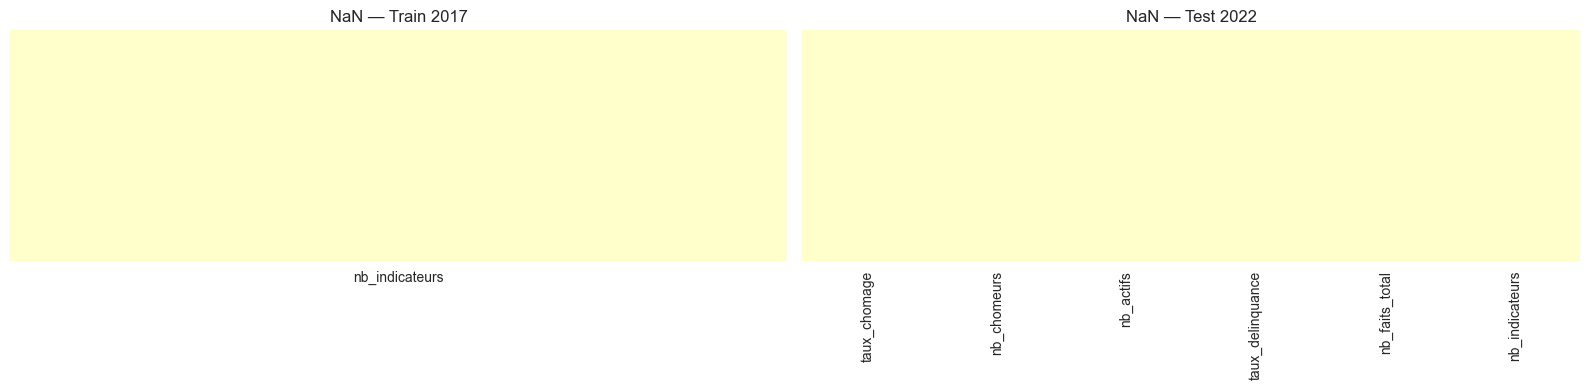

In [6]:
# Visualisation des NaN
if nan_train.empty and nan_test.empty:
    print("✅ Aucun NaN — pas de heatmap nécessaire")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    for ax, df, title in zip(axes, [df_train, df_test], ["Train 2017", "Test 2022"]):
        cols_nan = df.columns[df.isnull().any()].tolist()
        if cols_nan:
            sns.heatmap(df[cols_nan].isnull(), ax=ax, cbar=False,
                        yticklabels=False, cmap="YlOrRd")
            ax.set_title(f"NaN — {title}")
        else:
            ax.set_title(f"Pas de NaN — {title}")
    plt.tight_layout()
    plt.show()


### 2.4 Doublons

In [ ]:
dup_train = df_train.duplicated(subset=["code_commune"]).sum()
dup_test  = df_test.duplicated(subset=["code_commune"]).sum()
print(f"Doublons (code_commune) — Train : {dup_train}  |  Test : {dup_test}")

# Si doublons : conserver la première occurrence
if dup_train > 0:
    df_train = df_train.drop_duplicates(subset=["code_commune"], keep="first")
    print(f"  ✅ Train après suppression doublons : {len(df_train)} lignes")
if dup_test > 0:
    df_test  = df_test.drop_duplicates(subset=["code_commune"], keep="first")
    print(f"  ✅ Test  après suppression doublons : {len(df_test)} lignes")


### 2.5 Distribution de la variable cible

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors    = {"GAUCHE": "#e74c3c", "CENTRE": "#f39c12", "DROITE": "#2980b9", "DIVERS": "#7f8c8d"}

for ax, df, title in zip(axes, [df_train, df_test], ["Train 2017", "Test 2022"]):
    vc = df["bloc_vainqueur"].value_counts()
    vc.plot(kind="bar", ax=ax, color=[colors.get(b, "#95a5a6") for b in vc.index],
            edgecolor="white", width=0.6)
    ax.set_title(f"Blocs vainqueurs — {title}", fontsize=13, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Nombre de communes")
    for p in ax.patches:
        ax.annotate(f"{int(p.get_height())}",
                    (p.get_x() + p.get_width() / 2, p.get_height()),
                    ha="center", va="bottom", fontsize=11)
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

print("\nDistribution Train :")
print(df_train["bloc_vainqueur"].value_counts(normalize=True).map("{:.1%}".format).to_string())
print("\nDistribution Test :")
print(df_test["bloc_vainqueur"].value_counts(normalize=True).map("{:.1%}".format).to_string())


## 3. Nettoyage & préparation des features
### 3.1 Sélection et renommage des colonnes

In [ ]:
# Colonnes à conserver pour le ML (features numériques + target)
# On exclut : identifiants texte, noms de candidats, target encodée (redondante)

COLS_IDS = ["code_commune", "code_geo", "libelle_commune"]  # identifiants — conservés pour traçabilité

# Features électorales (participation + résultats par bloc)
FEATURES_ELECTORALES = [
    "inscrits", "abstentions", "votants", "exprimes", "pct_abstention",
    "pct_cand1", "pct_cand2", "pct_cand3", "pct_cand4", "pct_cand5",
    "pct_GAUCHE", "pct_CENTRE", "pct_DROITE", "pct_DIVERS",
]

# Features socio-économiques
FEATURES_SOCIO = [
    "taux_chomage",
    "population_mun",
    "taux_delinquance",
]

# On filtre pour ne garder que les colonnes qui existent réellement dans le dataset
features_electorales = [c for c in FEATURES_ELECTORALES if c in df_train.columns]
features_socio       = [c for c in FEATURES_SOCIO       if c in df_train.columns]
FEATURES             = features_electorales + features_socio
TARGET               = "bloc_vainqueur"

print(f"Features électorales retenues : {len(features_electorales)}")
for c in features_electorales: print(f"   • {c}")
print(f"\nFeatures socio-éco retenues : {len(features_socio)}")
for c in features_socio: print(f"   • {c}")
print(f"\nTotal features : {len(FEATURES)}")


### 3.2 Imputation des valeurs manquantes (moyenne)

In [ ]:
# Imputation par la MOYENNE du train (jamais du test pour éviter le data leakage)
moyennes_train = df_train[FEATURES].mean()

df_train[FEATURES] = df_train[FEATURES].fillna(moyennes_train)
df_test[FEATURES]  = df_test[FEATURES].fillna(moyennes_train)  # on utilise les moyennes du TRAIN

nan_restants_train = df_train[FEATURES].isnull().sum().sum()
nan_restants_test  = df_test[FEATURES].isnull().sum().sum()

print(f"✅ NaN restants après imputation — Train : {nan_restants_train}  |  Test : {nan_restants_test}")
print("\nMoyennes utilisées pour l'imputation :")
print(moyennes_train[moyennes_train.notna()].round(3).to_string())


### 3.3 Suppression des lignes sans variable cible

In [ ]:
for label, df in [("Train", df_train), ("Test", df_test)]:
    nb_avant = len(df)
    df.dropna(subset=[TARGET], inplace=True)
    print(f"{label} : {nb_avant} → {len(df)} lignes ({nb_avant - len(df)} supprimées)")


### 3.4 Corrélations entre features numériques

In [ ]:
plt.figure(figsize=(14, 10))
corr = df_train[FEATURES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, annot_kws={"size": 8})
plt.title("Corrélations entre features — Train 2017", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


## 4. Encodage & mise en forme pour le ML

In [ ]:
# Séparation X / y
X_train = df_train[FEATURES].copy()
y_train = df_train[TARGET].copy()
X_test  = df_test[FEATURES].copy()
y_test  = df_test[TARGET].copy()

# Encodage de la variable cible
le = LabelEncoder()
le.fit(y_train)
y_train_enc = le.transform(y_train)
y_test_enc  = le.transform(y_test)

print(f"Classes : {list(le.classes_)}")
print(f"X_train : {X_train.shape}  |  y_train : {len(y_train_enc)}")
print(f"X_test  : {X_test.shape}   |  y_test  : {len(y_test_enc)}")

# Normalisation (nécessaire pour LR, SVM, KNN)
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_test_sc   = scaler.transform(X_test)

print("\n✅ X_train_sc et X_test_sc normalisés (StandardScaler)")


## 5. Entraînement des modèles
### 5.1 Définition des modèles

In [ ]:
MODELES = {
    "Random Forest":        (RandomForestClassifier(n_estimators=200, max_depth=8,
                                                     random_state=42, n_jobs=-1),      False),
    "Logistic Regression":  (LogisticRegression(max_iter=1000, C=1.0,
                                                 random_state=42, n_jobs=-1),          True),
    "SVM":                  (SVC(kernel="rbf", C=1.0, gamma="scale",
                                 probability=True, random_state=42),                    True),
    "KNN":                  (KNeighborsClassifier(n_neighbors=7, metric="euclidean"),  True),
    "Gradient Boosting":    (GradientBoostingClassifier(n_estimators=150, max_depth=4,
                                                         learning_rate=0.1,
                                                         random_state=42),             False),
}
# Le booléen indique si le modèle nécessite les données normalisées

print("Modèles configurés :")
for nom, (modele, normalise) in MODELES.items():
    print(f"  {'✅' if normalise else '🌲'} {nom:25s} (normalisé={normalise})")


### 5.2 Cross-validation sur le train (StratifiedKFold)

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultats_cv = {}

print(f"{'Modèle':26s} {'CV Accuracy':>12s} {'±':>6s}")
print("-" * 46)

for nom, (modele, normalise) in MODELES.items():
    X = X_train_sc if normalise else X_train.values
    scores = cross_val_score(modele, X, y_train_enc, cv=cv, scoring="accuracy", n_jobs=-1)
    resultats_cv[nom] = scores
    print(f"{nom:26s} {scores.mean():.4f}      ± {scores.std():.4f}")


### 5.3 Entraînement final et évaluation sur le test

In [ ]:
resultats_test = {}

for nom, (modele, normalise) in MODELES.items():
    X_tr = X_train_sc if normalise else X_train.values
    X_te = X_test_sc  if normalise else X_test.values

    modele.fit(X_tr, y_train_enc)
    y_pred = modele.predict(X_te)

    acc = accuracy_score(y_test_enc, y_pred)
    f1  = f1_score(y_test_enc, y_pred, average="weighted")
    resultats_test[nom] = {"modele": modele, "y_pred": y_pred,
                           "accuracy": acc, "f1": f1, "normalise": normalise}

    print(f"\n{'='*50}")
    print(f"  {nom}")
    print(f"{'='*50}")
    print(f"  Accuracy : {acc:.4f}  |  F1 (weighted) : {f1:.4f}")
    print(classification_report(y_test_enc, y_pred, target_names=le.classes_))


## 6. Comparaison des modèles

In [ ]:
# Tableau comparatif
rows = []
for nom in MODELES:
    cv_mean = resultats_cv[nom].mean()
    cv_std  = resultats_cv[nom].std()
    acc     = resultats_test[nom]["accuracy"]
    f1      = resultats_test[nom]["f1"]
    rows.append({"Modèle": nom, "CV Acc (mean)": cv_mean, "CV Acc (±std)": cv_std,
                 "Test Accuracy": acc, "Test F1 (w)": f1})

df_scores = pd.DataFrame(rows).sort_values("Test Accuracy", ascending=False)
df_scores = df_scores.set_index("Modèle")
print(df_scores.round(4).to_string())


In [ ]:
# Graphique comparatif
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

noms    = df_scores.index.tolist()
palette = sns.color_palette("Set2", len(noms))

# CV vs Test accuracy
x = np.arange(len(noms))
width = 0.35
ax1.bar(x - width/2, df_scores["CV Acc (mean)"],  width, label="CV Accuracy",
        color=[p for p in palette], alpha=0.7, edgecolor="white")
ax1.bar(x + width/2, df_scores["Test Accuracy"],   width, label="Test Accuracy",
        color=[p for p in palette], alpha=1.0, edgecolor="white")
ax1.errorbar(x - width/2, df_scores["CV Acc (mean)"],
             yerr=df_scores["CV Acc (±std)"], fmt="none", color="black", capsize=4)
ax1.set_xticks(x)
ax1.set_xticklabels(noms, rotation=20, ha="right", fontsize=10)
ax1.set_ylim(0, 1)
ax1.set_ylabel("Accuracy")
ax1.set_title("CV vs Test Accuracy", fontsize=12, fontweight="bold")
ax1.legend()
ax1.axhline(y=0.5, color="grey", linestyle="--", alpha=0.5, label="Baseline 50%")

# F1 scores
ax2.bar(noms, df_scores["Test F1 (w)"], color=palette, edgecolor="white")
ax2.set_ylim(0, 1)
ax2.set_ylabel("F1 Score (weighted)")
ax2.set_title("F1 Score sur le jeu de test", fontsize=12, fontweight="bold")
ax2.tick_params(axis="x", rotation=20)
for bar, val in zip(ax2.patches, df_scores["Test F1 (w)"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{val:.3f}", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

meilleur = df_scores["Test Accuracy"].idxmax()
print(f"\n🏆 Meilleur modèle : {meilleur}  (Accuracy test = {df_scores.loc[meilleur, 'Test Accuracy']:.4f})")


## 7. Matrices de confusion

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for ax, (nom, res) in zip(axes, resultats_test.items()):
    cm  = confusion_matrix(y_test_enc, res["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{nom}\nAcc={res['accuracy']:.3f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")

# Masquer le 6e subplot si 5 modèles
for ax in axes[len(resultats_test):]:
    ax.set_visible(False)

plt.suptitle("Matrices de confusion — Jeu de test 2022", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()


## 8. Importance des features (Random Forest & Gradient Boosting)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, nom_modele in zip(axes, ["Random Forest", "Gradient Boosting"]):
    modele  = resultats_test[nom_modele]["modele"]
    importances = pd.Series(modele.feature_importances_, index=FEATURES)
    importances = importances.sort_values(ascending=True).tail(15)

    importances.plot(kind="barh", ax=ax, color="#3498db", edgecolor="white")
    ax.set_title(f"Top 15 features — {nom_modele}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Importance")
    ax.tick_params(axis="y", labelsize=9)
    ax.axvline(x=0, color="black", linewidth=0.5)

plt.tight_layout()
plt.show()


## 9. Analyse des erreurs — Meilleur modèle

In [ ]:
meilleur_nom    = df_scores["Test Accuracy"].idxmax()
meilleur_modele = resultats_test[meilleur_nom]

df_analyse = df_test[COLS_IDS + [TARGET]].copy()
df_analyse["prediction"]   = le.inverse_transform(meilleur_modele["y_pred"])
df_analyse["correct"]      = df_analyse[TARGET] == df_analyse["prediction"]

# Ajouter les features socio pour analyse
for col in features_socio:
    if col in df_test.columns:
        df_analyse[col] = df_test[col].values

nb_erreurs = (~df_analyse["correct"]).sum()
print(f"Modèle : {meilleur_nom}")
print(f"Erreurs : {nb_erreurs} / {len(df_analyse)} communes ({nb_erreurs/len(df_analyse)*100:.1f}%)")
print(f"\nType d'erreurs :")
erreurs = df_analyse[~df_analyse["correct"]]
print(erreurs.groupby([TARGET, "prediction"]).size().sort_values(ascending=False).to_string())


In [ ]:
# Top 10 communes les plus mal prédites (avec contexte)
print("\nExemples de communes mal classifiées :")
cols_affichage = ["libelle_commune", TARGET, "prediction"] + features_socio[:3]
cols_affichage = [c for c in cols_affichage if c in df_analyse.columns]
print(erreurs[cols_affichage].head(10).to_string(index=False))


## 10. Synthèse et recommandations

In [ ]:
print("=" * 60)
print("SYNTHÈSE FINALE — ElectioAnalytics")
print("=" * 60)
print(f"\nDataset Train : {len(df_train)} communes (élections 2017)")
print(f"Dataset Test  : {len(df_test)} communes (élections 2022)")
print(f"Features      : {len(FEATURES)} variables")
print(f"Classes       : {list(le.classes_)}")

print("\n" + "-" * 60)
print("Performances comparées (jeu de test 2022) :")
print("-" * 60)
print(df_scores[["CV Acc (mean)", "Test Accuracy", "Test F1 (w)"]].round(4).to_string())

print(f"\n🏆 Meilleur modèle : {meilleur_nom}")
print(f"   Accuracy test   : {df_scores.loc[meilleur_nom, 'Test Accuracy']:.4f}")
print(f"   F1 (weighted)   : {df_scores.loc[meilleur_nom, 'Test F1 (w)']:.4f}")

print("\n⚠️  Note : dataset ~650 communes → k-fold cross-validation recommandé")
print("   Les résultats peuvent varier selon le seed aléatoire.")
